<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB35 · Robots con patas: Hopper y Walker2d

**Parte 4 · Aprendizaje por refuerzo de verdad — Lección 8**

> En el **NB34** tu agente de Stable-Baselines3 sostuvo el péndulo invertido de MuJoCo mil pasos de mil. Era tu primer robot de física real... pero no tenía patas: era un carrito sobre un raíl.

Hoy llegan las **patas**. Vas a conocer y entrenar los dos robots con patas más famosos de la investigación en aprendizaje por refuerzo:

- **Hopper** ("saltarín"): **una sola pata** que tiene que avanzar a saltos sin caerse.
- **Walker2d** ("andador en 2D"): **dos piernas** que tienen que andar (o correr).

Son los "hermanos pequeños" del humanoide: viven en un **plano** (solo pueden moverse hacia delante, hacia atrás, arriba y abajo, y girar en ese plano, como un dibujo animado de perfil), así
que no pueden caerse de lado. Eso los hace mucho más fáciles que un humanoide en 3D... pero ya tienen **todos** los problemas de verdad de la locomoción: golpear el suelo, impulsarse, pasar por
el aire, aterrizar. Y una recompensa que se puede **engañar**.

Como siempre, primero entenderemos los cuerpos y las reglas del juego. Después, a entrenar.


## 1 · Del palo a las patas: qué cambia

Con el palo de escoba y el péndulo, el robot estaba siempre **pegado** a algo: el palo, a la mano; el carrito, al raíl. Para moverse, bastaba empujar.

Con patas, el robot está **suelto**. La única forma de moverse es **empujar el suelo** con los pies, y que el suelo empuje de vuelta (la tercera ley de Newton: si empujas el suelo hacia atrás, el
suelo te empuja hacia delante; NB02). Eso trae tres problemas nuevos:

1. **Los contactos.** Un pie puede estar **tocando** el suelo o **no**. Cuando toca, puede empujar; cuando no, los motores de la pierna no sirven para avanzar. Y el momento del choque (el
   **aterrizaje**) es violento: fuerzas enormes durante un instante. Para el simulador es lo más difícil de calcular, y para el robot, lo más difícil de controlar.
2. **Las fases en el aire.** Al saltar o correr, hay momentos en los que **ningún** pie toca el suelo. Ahí el robot no puede hacer nada para cambiar su trayectoria (sigue la parábola de la
   pelota del NB07): solo puede preparar las piernas para el aterrizaje. Hay que **planificar** antes de despegar.
3. **La subactuación** (NB02): el torso no tiene motor que lo sujete al mundo. Su posición y su inclinación solo se controlan **indirectamente**, a través de las piernas y el suelo. Es el palo de
   escoba otra vez, pero ahora el palo es **tu propio cuerpo**.

Y una cuarta, más sutil: andar es un movimiento **cíclico** (paso, paso, paso...). La política tiene que descubrir, sin que nadie se lo diga, un **ritmo** que se repita. Nadie le enseña qué es
"un paso".


## 2 · Conoce a Hopper

Primero, las herramientas de siempre:

In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"          # dibujar sin pantalla (NB15)

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(2)


Y ahora, el cuerpo de Hopper. MuJoCo describe cada robot con un **modelo** (el "plano de IKEA" del NB01): sus piezas rígidas (*bodies*), sus articulaciones, sus motores. Gymnasium nos deja
consultarlo a través de `entorno.unwrapped.model` (`unwrapped` quita los envoltorios del NB25 y da el entorno de MuJoCo "desnudo"):


In [2]:
import mujoco

hopper = gym.make("Hopper-v5")
modelo_mujoco = hopper.unwrapped.model

piezas = [mujoco.mj_id2name(modelo_mujoco, mujoco.mjtObj.mjOBJ_BODY, i) for i in range(modelo_mujoco.nbody)]
print("Piezas:", piezas)
print("Masa de cada pieza (kg):", modelo_mujoco.body_mass.round(2))
print(f"Masa total: {modelo_mujoco.body_mass.sum():.1f} kg")
print("Motores:", modelo_mujoco.nu, "| multiplicador de fuerza de cada uno:", modelo_mujoco.actuator_gear[:, 0])


Piezas: ['world', 'torso', 'thigh', 'leg', 'foot']
Masa de cada pieza (kg): [0.   3.67 4.06 2.78 5.32]
Masa total: 15.8 kg
Motores: 3 | multiplicador de fuerza de cada uno: [200. 200. 200.]


Lo que dice el plano:

```
            ┌─┐
            │ │  torso  (la pieza más pesada)
            │ │
            └┬┘  ◄── motor 1: CADERA
             │
             │   thigh  (muslo)
             │
             ●   ◄── motor 2: RODILLA
             │
             │   leg  (pierna)
             │
             ●   ◄── motor 3: TOBILLO
          ───┴───  foot  (pie)
```

- **`world`** no es una pieza del robot: es el **mundo** (el suelo), que MuJoCo cuenta como pieza número 0, con masa 0.
- Cuatro piezas de verdad: **torso, muslo, pierna y pie**, unas 16 kg en total.
- **Tres motores**, uno en cada bisagra (NB01): cadera, rodilla y tobillo. El **multiplicador** (*gear*, "engranaje") de 200 significa que una acción de 1 se convierte en un par de giro de 200 (NB01:
  el "par" es la fuerza de giro de un motor; en el NB37 verás exactamente qué es y en qué se mide). Por eso las acciones van de −1 a 1: el robot dice "cuánto de su fuerza máxima" usa cada motor.

Ahora, lo que **ve** y lo que **hace**:


In [3]:
print("Observación:", hopper.observation_space)
print("Acción:     ", hopper.action_space)
print("Duración de un paso:", hopper.unwrapped.dt, "s  →", round(1 / hopper.unwrapped.dt), "decisiones por segundo")
print("Pasos máximos por episodio:", hopper.spec.max_episode_steps)


Observación: Box(-inf, inf, (11,), float64)
Acción:      Box(-1.0, 1.0, (3,), float32)
Duración de un paso: 0.008 s  → 125 decisiones por segundo
Pasos máximos por episodio: 1000


- **Observación: 11 números.** 5 de **posición** (la altura del torso, su inclinación, y los ángulos de las tres articulaciones) y 6 de **velocidad** (hacia delante, hacia arriba, de giro del torso y de las
  tres articulaciones). Fíjate en lo que **no** ve: **dónde está** en el eje hacia delante (la x). A propósito: así la política no puede aprender cosas como "en el metro 3 salto", y lo que aprenda
  sirve en cualquier sitio.
- **Acción: 3 números** entre −1 y 1, uno por motor.
- **Un paso dura 0,008 segundos**: el robot decide **125 veces por segundo**. (MuJoCo calcula la física en pasitos de 0,002 s y el robot decide uno de cada 4, como el humanoide del NB00, que decidía
  uno de cada 5.) Así que un episodio completo de 1.000 pasos son **8 segundos** de vida.


## 3 · La recompensa, desmontada

¿Qué premia Hopper? Su recompensa en cada paso es la suma de **tres** piezas (como la del humanoide del NB04):

```
recompensa = sobrevivir  +  avanzar  −  gastar
              (+1 si       (velocidad   (0,001 × suma de
             está sano)   hacia delante)  acciones al cuadrado)
```

1. **Sobrevivir** (*healthy reward*): **+1** por cada paso que el robot está "sano".
2. **Avanzar** (*forward reward*): su **velocidad hacia delante**, en metros por segundo. Ir hacia atrás resta.
3. **Gastar** (*control cost*): un pequeño castigo por usar mucha fuerza (las acciones al cuadrado, NB28), para que no haga movimientos bruscos sin necesidad.

¿Y qué es estar "sano"? Tres condiciones (si falla cualquiera, el episodio **termina**):

- el torso a **más de 0,7 m** de altura (no se ha desplomado);
- el torso inclinado **menos de 0,2 radianes** (unos 11°, como el péndulo del NB34);
- ningún número de la observación desbocado (más de 100: la física "explotó").

No hace falta fiarse de mí: el entorno **cuenta** cada pieza en el diccionario `info` que devuelve `step` (NB25). Demos unos pasos al azar:


In [4]:
observacion, info = hopper.reset(seed=0)
for paso in range(5):
    observacion, recompensa, terminado, truncado, info = hopper.step(hopper.action_space.sample())
    print(f"paso {paso} | total {recompensa:6.3f} = sobrevivir {info['reward_survive']:.0f} "
          f"+ avance {info['reward_forward']:6.3f} + control {info['reward_ctrl']:7.4f} | altura del torso {observacion[0]:.3f} m")


paso 0 | total  0.968 = sobrevivir 1 + avance -0.031 + control -0.0005 | altura del torso 1.247 m
paso 1 | total  0.892 = sobrevivir 1 + avance -0.107 + control -0.0009 | altura del torso 1.247 m
paso 2 | total  0.823 = sobrevivir 1 + avance -0.176 + control -0.0010 | altura del torso 1.245 m
paso 3 | total  0.857 = sobrevivir 1 + avance -0.141 + control -0.0016 | altura del torso 1.243 m
paso 4 | total  0.847 = sobrevivir 1 + avance -0.151 + control -0.0019 | altura del torso 1.240 m


Cada recompensa es, exactamente, la suma de las tres piezas. La de sobrevivir domina (+1), el avance es pequeño (moverse al azar no lleva a ningún sitio) y el gasto es diminuto. Y la primera
observación, como ves, es la **altura** del torso: algo más de 1,2 m al empezar.

### Las políticas de referencia

Como en el NB04 y el NB11, antes de entrenar medimos dos referencias: el **azar** (acciones al azar) y **quieto** (todas las acciones a cero, sin usar los motores). Diez episodios de cada una:


In [5]:
def jugar_episodios(entorno, politica, n=10):
    retornos, duraciones, distancias = [], [], []
    for semilla in range(n):
        observacion, info = entorno.reset(seed=semilla)
        retorno, pasos = 0.0, 0
        while True:
            observacion, recompensa, terminado, truncado, info = entorno.step(politica(observacion))
            retorno += recompensa
            pasos += 1
            if terminado or truncado:
                break
        retornos.append(retorno)
        duraciones.append(pasos)
        distancias.append(info["x_position"])
    return np.mean(retornos), np.mean(duraciones), np.mean(distancias)

azar = lambda obs: hopper.action_space.sample()
quieto = lambda obs: np.zeros(3)
for nombre, politica in [("azar", azar), ("quieto", quieto)]:
    r, d, x = jugar_episodios(hopper, politica)
    print(f"{nombre:>6}: retorno {r:6.1f} | dura {d:5.1f} pasos ({d * 0.008:.2f} s) | acaba en x = {x:+.2f} m")


  azar: retorno   28.5 | dura  29.9 pasos (0.24 s) | acaba en x = -0.00 m


quieto: retorno  146.1 | dura 148.8 pasos (1.19 s) | acaba en x = -0.01 m


(`lambda` es la forma corta de escribir una función de una línea, NB23. Y `info["x_position"]` es la posición hacia delante, que el robot no ve pero el entorno sí apunta.)

- **Al azar**, Hopper se cae enseguida: unas pocas decenas de pasos, **un cuarto de segundo** o menos (la cifra exacta cambia en cada ejecución, porque las acciones al azar son distintas cada vez). Sus motores son tan fuertes (×200) que unas sacudidas al azar lo tumban al instante.
- **Quieto**, sin mover ningún motor, dura bastante más: alrededor de 150 pasos (1,2 s), lo que tarda en **desplomarse** poco a poco por su propio peso, como un muñeco de trapo (el humanoide del NB04
  hacía lo mismo). Y saca más puntos que el azar, sin avanzar nada.

El techo, como referencia: un Hopper bien entrenado saca **más de 3.000** puntos (1.000 por sobrevivir los 1.000 pasos, más más de 2.000 por avanzar a más de 2 m/s).


## 4 · La trampa de sobrevivir

Mira la recompensa con ojos de tramposo (NB04). Sobrevivir da **+1 por paso**, pase lo que pase. Si el robot consiguiera **quedarse de pie, quieto**, durante los 1.000 pasos, sacaría **1.000 puntos**
sin dar ni un salto. Saltar, en cambio, es **arriesgado**: cada salto es una ocasión de caerse y perderlo todo.

Así que al principio del entrenamiento, el camino fácil para mejorar es aprender a **no caerse**, y a veces el agente se queda ahí: un **óptimo local** (NB17), como el humanoide quieto del NB04 que sacaba
5.000. Lo que lo empuja a moverse es el término de **avance**.

¿Qué pasa si **quitamos** el término de avance? Gymnasium deja cambiar los pesos de la recompensa al crear el entorno: `forward_reward_weight=0` multiplica el avance por 0. Hagamos el experimento:
entrenamos un PPO con la configuración del NB34 durante 106.496 pasos (unos dos minutos y medio en la Pi) en un Hopper que **solo** cobra por sobrevivir, y miramos qué hace.


In [6]:
import time
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

inicio = time.time()
entornos_vida = make_vec_env("Hopper-v5", n_envs=4, seed=0, env_kwargs=dict(forward_reward_weight=0.0))
agente_vida = PPO("MlpPolicy", entornos_vida, seed=0)
agente_vida.learn(total_timesteps=106_496)
print(f"Entrenado en {time.time() - inicio:.0f} s")

hopper_vida = gym.make("Hopper-v5", forward_reward_weight=0.0)
politica_vida = lambda obs: agente_vida.predict(obs, deterministic=True)[0]
r, d, x = jugar_episodios(hopper_vida, politica_vida)
print(f"Solo vida: retorno {r:6.1f} | dura {d:6.1f} pasos | acaba en x = {x:+.2f} m")


Entrenado en 143 s


Solo vida: retorno  999.8 | dura 1000.0 pasos | acaba en x = +0.06 m


(`env_kwargs` pasa argumentos a `gym.make` para crear cada copia, NB23. Y 106.496 = 13 lotes exactos de 8.192 pasos: como aprendimos en el NB34, mejor pedir múltiplos del lote.)

Lo ha clavado: **1.000 pasos** de 1.000, es decir, aguanta el episodio entero en **todos** los episodios, y saca **999,8** de los 1.000 puntos posibles (lo que falta es el pequeño gasto de control). ¿Y cuánto avanza? **6 centímetros** en 8 segundos. Ha aprendido a quedarse **de pie, quieto**, en solo dos minutos y medio de entrenamiento.

No ha hecho "trampa": ha hecho **exactamente** lo que le hemos pedido. Le pagábamos por no caerse y ha encontrado la forma más segura de no caerse: no moverse. Esa es la lección del NB04 vista en directo: **el agente optimiza lo que pagas, no lo que querías**. El término de avance es lo único que lo empuja a arriesgarse a saltar.


## 5 · Normalizar las observaciones: `VecNormalize`

Antes de entrenar Hopper de verdad, una herramienta nueva e importantísima para robots.

En el NB32 tuvimos que **escalar** a mano las entradas de las redes (inclinación entre 10, velocidad entre 20), porque las redes aprenden mal con números grandes o de escalas muy distintas. Hopper tiene 11
números en la observación, de escalas muy diferentes (una altura de ~1,2 m, ángulos de décimas de radián, velocidades de articulación que pueden llegar a decenas). El humanoide tiene 348. Elegir a mano
una escala para cada uno sería un infierno.

**`VecNormalize`** lo hace solo. Es un **envoltorio** para entornos vectorizados que:

1. Lleva la cuenta de la **media** y la **desviación típica** de cada número de la observación, a medida que el robot juega (una media "móvil", que se actualiza con cada paso, NB28).
2. A cada observación le resta su media y la divide por su desviación (la normalización del NB27 y del NB30). Así, la red siempre recibe números de **tamaño parecido a 1**.
3. Hace algo parecido con las **recompensas**, para que la escala de las ventajas y del crítico sea cómoda.

Dos **trampas** que hay que conocer (muchísima gente cae en ellas):

- **Las estadísticas son parte del agente.** La red ha aprendido a leer observaciones **normalizadas con esas medias y desviaciones concretas**. Si guardas el modelo y no guardas las estadísticas,
  al cargarlo le llegarán números en otra escala y hará disparates. Hay que guardar **las dos cosas**.
- **Al evaluar, no hay que seguir actualizando las estadísticas** (`training=False`) ni normalizar la recompensa (`norm_reward=False`), para que la nota sea la recompensa de verdad.

Comparemos un entrenamiento corto de Hopper **sin** y **con** `VecNormalize`, 106.496 pasos cada uno, la misma semilla (unos cinco minutos en total):


In [7]:
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.evaluation import evaluate_policy

def examen_normalizado(agente, nombre, estadisticas=None, n=5):
    entorno = make_vec_env(nombre, n_envs=1, seed=123)
    if estadisticas is not None:
        entorno = VecNormalize(entorno, training=False, norm_reward=False)
        entorno.obs_rms = estadisticas                 # las medias y desviaciones del entrenamiento
    media, desviacion = evaluate_policy(agente, entorno, n_eval_episodes=n, deterministic=True)
    return media, desviacion

resultados = {}
for usar_normalizacion in [False, True]:
    inicio = time.time()
    entornos = make_vec_env("Hopper-v5", n_envs=4, seed=0)
    if usar_normalizacion:
        entornos = VecNormalize(entornos)
    agente = PPO("MlpPolicy", entornos, seed=0)
    agente.learn(total_timesteps=106_496)
    estadisticas = entornos.obs_rms if usar_normalizacion else None
    resultados[usar_normalizacion] = examen_normalizado(agente, "Hopper-v5", estadisticas)
    print(f"{'con' if usar_normalizacion else 'sin'} VecNormalize: nota {resultados[usar_normalizacion][0]:7.1f} "
          f"± {resultados[usar_normalizacion][1]:5.1f} | {time.time() - inicio:.0f} s")


sin VecNormalize: nota   386.9 ±   1.1 | 147 s


con VecNormalize: nota   301.2 ±   1.1 | 149 s


(`obs_rms` son las estadísticas de la observación: *rms* viene de *running mean and std*, "media y desviación móviles".)

¡Sorpresa! **Sin** normalizar saca **387** puntos y **con** normalización, **301**. En este experimento corto, `VecNormalize` **no** gana: pierde.

¿Entonces no sirve? Hay que mirarlo con calma, como científicos:

- Los dos agentes están todavía en la fase de "aprender a no caerse" (fíjate en la desviación diminuta: los 5 episodios se caen casi igual). La diferencia entre 301 y 387 a estas alturas es pequeña, y con **una sola semilla** (NB34) no demuestra nada, ni a favor ni en contra.
- La ventaja de normalizar se nota **a la larga** y crece con el **número** de observaciones: con las 11 de Hopper, la red se las puede arreglar con números algo desiguales; con las 348 del humanoide, no.
- Los entrenamientos largos de la siguiente sección **sí** usan `VecNormalize`, y llegan a más de 3.500 puntos. Es la práctica habitual con robots.

Para **demostrarlo** de verdad habría que entrenar un millón de pasos con y sin normalización, con varias semillas cada uno: horas de Pi. Esta es una lección importante del oficio: **un experimento corto con una semilla no demuestra nada**, y es mejor decirlo que fingir que el resultado salió como se esperaba.


## 6 · El entrenamiento largo

Para que Hopper salte **bien** hacen falta del orden de **un millón de pasos**. En la Raspberry Pi eso son bastantes minutos por robot (mira el registro de abajo), demasiado para ejecutarlo cada vez que abras
este cuaderno. Así que lo he entrenado **antes**, con este script (un fichero `.py`, como los del NB26; lo tienes en `notebooks/entrenar_largo.py`), y he guardado el resultado en la carpeta `modelos/` del curso:

```python
# entrenar_largo.py  —  uso: python entrenar_largo.py Hopper-v5 defecto 1000000
import sys, time, torch
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.evaluation import evaluate_policy

torch.set_num_threads(1)
nombre, configuracion, total = sys.argv[1], sys.argv[2], int(sys.argv[3])
entornos = VecNormalize(make_vec_env(nombre, n_envs=4, seed=0))
ajustes = dict(seed=0)
if configuracion == "afinado":
    ajustes.update(n_steps=512, batch_size=64, learning_rate=3e-4,
                   policy_kwargs=dict(log_std_init=-1, net_arch=dict(pi=[256, 256], vf=[256, 256])))
agente = PPO("MlpPolicy", entornos, **ajustes)

examen = VecNormalize(make_vec_env(nombre, n_envs=1, seed=123), training=False, norm_reward=False)
inicio = time.time()
while agente.num_timesteps < total:
    agente.learn(100_352, reset_num_timesteps=False)          # un tramo
    examen.obs_rms = entornos.obs_rms
    nota, desviacion = evaluate_policy(agente, examen, n_eval_episodes=5, deterministic=True)
    print(nombre, configuracion, agente.num_timesteps, round(nota, 1), round(desviacion, 1), f"{time.time() - inicio:.0f}s")
    agente.save(f"{nombre}_{configuracion}")                   # el agente...
    entornos.save(f"{nombre}_{configuracion}_norm.pkl")        # ...y sus estadísticas: ¡las dos cosas!
```

Lo entrené con dos configuraciones: **`defecto`** (los ajustes de SB3 del NB34) y **`afinado`** (lotes más pequeños, redes de 256 neuronas y una campana inicial más estrecha, σ = e^(−1) ≈ 0,37).
Las notas de su registro, tramo a tramo, están copiadas aquí (cada línea del registro: pasos, nota media de 5 episodios):


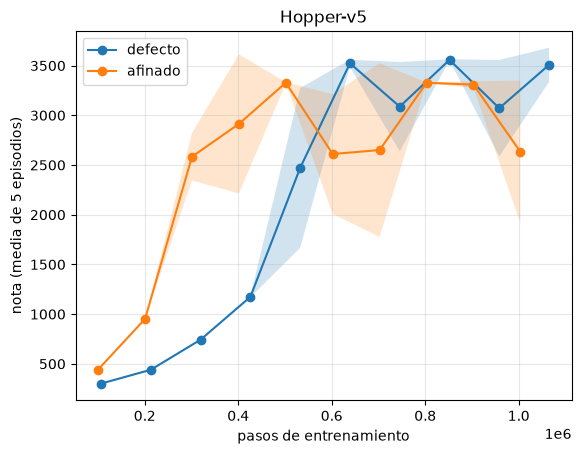

In [8]:
# Registro de entrenar_largo.py, tramo a tramo: (pasos, nota media de 5 episodios, desviación)
hopper_defecto = [(106_496, 301.2, 1.1), (212_992, 440.4, 1.4), (319_488, 742.9, 2.1), (425_984, 1173.7, 5.0),
                  (532_480, 2471.0, 803.7), (638_976, 3523.5, 36.1), (745_472, 3087.5, 449.1), (851_968, 3557.9, 5.7),
                  (958_464, 3071.9, 484.7), (1_064_960, 3508.0, 172.3)]
hopper_afinado = [(100_352, 442.6, 1.4), (200_704, 951.7, 2.6), (301_056, 2583.6, 238.5), (401_408, 2913.5, 700.5),
                  (501_760, 3328.2, 5.4), (602_112, 2610.6, 601.9), (702_464, 2650.7, 874.0), (802_816, 3327.5, 3.6),
                  (903_168, 3308.5, 33.3), (1_003_520, 2633.3, 716.2)]

def dibujar_registro(titulo, curvas):
    for nombre, registro in curvas.items():
        pasos = np.array([p for p, nota, desviacion in registro])
        notas = np.array([nota for p, nota, desviacion in registro])
        desviaciones = np.array([desviacion for p, nota, desviacion in registro])
        plt.plot(pasos, notas, marker="o", label=nombre)
        plt.fill_between(pasos, notas - desviaciones, notas + desviaciones, alpha=0.2)   # la franja: nota ± desviación
    plt.xlabel("pasos de entrenamiento")
    plt.ylabel("nota (media de 5 episodios)")
    plt.title(titulo)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

dibujar_registro("Hopper-v5", {"defecto": hopper_defecto, "afinado": hopper_afinado})


(`fill_between` rellena el espacio entre dos curvas: aquí, la franja de la nota **menos** la desviación a la nota **más** la desviación. Cuanto más ancha, más **distintos** entre sí fueron los 5 episodios del examen.)

Un detalle del registro: los tramos de `defecto` son de 106.496 pasos y los de `afinado` de 100.352. Es la lección del NB34: `learn` siempre juega **lotes completos**, y los lotes son distintos (4 copias × 2.048 = 8.192 pasos en `defecto`; 4 × 512 = 2.048 en `afinado`). Cada robot tardó en total algo más de **una hora** (`defecto`) y **hora y media** (`afinado`), con los cuatro entrenamientos a la vez en la Pi, uno por núcleo.

Lo que cuentan las curvas:

- **Al principio, las dos se arrastran** (300–950 puntos en los primeros 200.000 pasos): el agente está aprendiendo a **no caerse**, la parte fácil de la recompensa (sección 4).
- **De repente, despegan.** `afinado` descubre el salto antes (2.584 a los 300.000 pasos); `defecto`, hacia los 500.000. Ese salto brusco es típico del RL: durante mucho tiempo parece que no pasa nada y, cuando el agente descubre "el truco", la nota se dispara.
- **Las dos llegan arriba**, a unos **3.300–3.550 puntos**: más de 3.000, el nivel de un Hopper bien entrenado.
- **Pero zigzaguean.** Mira `defecto`: 3.523 → 3.087 → 3.558 → 3.072 → 3.508. Y fíjate en las franjas: a veces la desviación es de **±800**. Eso significa que, con **la misma** política, unos episodios aguantan los 1.000 pasos y otros se caen a mitad. Cada episodio empieza con una postura un pelín distinta (el entorno añade un ruido diminuto al reiniciar), y la política está tan al **límite** (saltar deprisa sin caerse) que a veces ese pelín basta.
- **`afinado` es más rápido pero más inestable**: aprende antes, pero oscila más. Una explicación probable: con lotes más pequeños, cada actualización se basa en menos experiencia y es más "ruidosa" (NB33).

Y una lección de profesional que salta a la vista: **el fichero guardado es el del ÚLTIMO tramo, no el del mejor.** `afinado` llegó a 3.328 puntos, pero acabó en 2.633: su fichero guarda la versión de 2.633. En los proyectos de verdad se guarda **el mejor** examen (SB3 trae una herramienta para eso, `EvalCallback`, "llamada de evaluación", que examina cada cierto tiempo y guarda el mejor). Aquí nos quedamos con `defecto`, que acabó en un sólido **3.508 ± 172**.

Último aviso de honestidad (NB34): esto es **una** semilla. Con otra, el orden entre `defecto` y `afinado` podría cambiar. Para afirmar en serio "esta configuración es mejor" harían falta varias semillas de cada una.

Ahora, a **cargar** el agente entrenado y examinarlo. Para cargarlo hacen falta las dos piezas: el agente (`PPO.load`) y sus estadísticas (`VecNormalize.load`, que necesita un entorno al que envolver):


In [9]:
from pathlib import Path

MODELOS = Path("modelos")

def cargar(nombre, configuracion):
    agente = PPO.load(MODELOS / f"{nombre}_{configuracion}")
    entorno = VecNormalize.load(MODELOS / f"{nombre}_{configuracion}_norm.pkl", make_vec_env(nombre, n_envs=1, seed=0))
    entorno.training, entorno.norm_reward = False, False
    return agente, entorno

def politica_de(agente, entorno_normalizado):
    # traduce una observación "cruda" a la normalizada antes de pedir la acción
    return lambda obs: agente.predict(entorno_normalizado.normalize_obs(obs), deterministic=True)[0]

agente_hopper, normalizador_hopper = cargar("Hopper-v5", "defecto")
politica_hopper = politica_de(agente_hopper, normalizador_hopper)
r, d, x = jugar_episodios(hopper, politica_hopper)
print(f"Hopper entrenado: retorno {r:7.1f} | dura {d:6.1f} pasos | recorre {x:5.2f} m en {d * 0.008:.1f} s "
      f"(≈ {x / (d * 0.008):.2f} m/s)")


Hopper entrenado: retorno  3558.8 | dura  969.1 pasos | recorre 20.73 m en 7.8 s (≈ 2.67 m/s)


(`normalize_obs` aplica a una observación la misma normalización que veía el agente al entrenar. Así podemos usar el `jugar_episodios` de siempre, con el entorno "crudo".)

**3.559 puntos** de media en 10 episodios. Dura **969 pasos** de media: casi siempre aguanta los 1.000, pero en algún episodio se cae antes (la inestabilidad que vimos en las franjas). Y recorre **20,7 metros** en unos 7,8 segundos: **2,67 m/s**, casi 10 km/h. Un robot de 16 kg con **una sola pata** que va a trote ligero. Compáralo con el principio: al azar duraba 20 pasos; quieto, unos 150.

Y ahora, a **verlo**. Grabamos un episodio en GIF, como en el NB34, con la cámara siguiendo al robot:


100 fotos


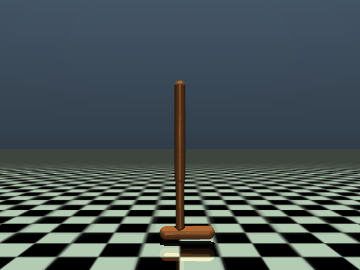

In [10]:
import imageio
from IPython.display import Image

def grabar(nombre, politica, ruta, pasos=300, semilla=0, cada=3):
    camara = gym.make(nombre, render_mode="rgb_array", width=360, height=270)
    observacion, info = camara.reset(seed=semilla)
    fotos = []
    for paso in range(pasos):
        observacion, recompensa, terminado, truncado, info = camara.step(politica(observacion))
        if paso % cada == 0:
            fotos.append(camara.render())
        if terminado or truncado:
            break
    camara.close()
    imageio.mimsave(ruta, fotos, fps=round(1 / (0.008 * cada)), loop=0)
    return len(fotos)

os.makedirs("assets", exist_ok=True)
n = grabar("Hopper-v5", politica_hopper, "assets/nb35_hopper.gif")
print(n, "fotos")
Image(filename="assets/nb35_hopper.gif")


Fíjate en cómo lo hace:

- Empieza recto y en seguida **se agacha**: dobla la rodilla e inclina un poco el torso hacia delante. Agachado, su centro de masas está más bajo y es más difícil volcar.
- Avanza a base de **saltitos cortos, rápidos y casi rasantes**, no de saltos altos de canguro. Un salto alto tiene una fase en el aire larga (sección 1), en la que no puede corregir nada, y un aterrizaje violento: demasiado riesgo.
- La pierna trabaja como un **muelle**: el pie aterriza, la rodilla se dobla y absorbe el golpe, y el **tobillo** da el empujón del siguiente salto.

Nadie le ha enseñado nada de esto. Ni "agáchate", ni "salta bajito", ni "usa el tobillo". Lo ha descubierto él solo, a base de un millón de intentos y de la recompensa "avanza sin caerte".


## 7 · Walker2d: dos piernas

Ahora, el hermano mayor. **Walker2d** es Hopper con **dos piernas**: el mismo torso, y cada pierna con muslo, pierna y pie, cadera, rodilla y tobillo. **Seis motores**:


In [11]:
walker = gym.make("Walker2d-v5")
modelo_walker = walker.unwrapped.model
print("Piezas:", [mujoco.mj_id2name(modelo_walker, mujoco.mjtObj.mjOBJ_BODY, i) for i in range(modelo_walker.nbody)])
print(f"Masa total: {modelo_walker.body_mass.sum():.1f} kg | motores: {modelo_walker.nu} (multiplicador {modelo_walker.actuator_gear[0, 0]:.0f})")
print("Observación:", walker.observation_space.shape, "| acción:", walker.action_space.shape)

for nombre, politica in [("azar", lambda obs: walker.action_space.sample()), ("quieto", lambda obs: np.zeros(6))]:
    r, d, x = jugar_episodios(walker, politica)
    print(f"{nombre:>6}: retorno {r:6.1f} | dura {d:5.1f} pasos | acaba en x = {x:+.2f} m")


Piezas: ['world', 'torso', 'thigh', 'leg', 'foot', 'thigh_left', 'leg_left', 'foot_left']
Masa total: 23.7 kg | motores: 6 (multiplicador 100)
Observación: (17,) | acción: (6,)
  azar: retorno    2.0 | dura  18.2 pasos | acaba en x = -0.12 m


quieto: retorno   93.5 | dura 118.8 pasos | acaba en x = -0.19 m


Las piezas con `_left` son las de la pierna **izquierda**. Observa 17 números (8 posiciones sin la x, 9 velocidades) y controla 6 motores, con la mitad de fuerza que Hopper (multiplicador 100) pero
para un cuerpo más pesado. La recompensa es **la misma**: sobrevivir + avanzar − gastar. Lo "sano" cambia un poco: el torso entre 0,8 y 2 m de altura, e inclinado menos de 1 radián (unos 57°: le
deja inclinarse mucho más que a Hopper).

Al azar o quieto, se cae enseguida, como Hopper. Lo entrenamos con el mismo script y las mismas dos configuraciones. Su registro:


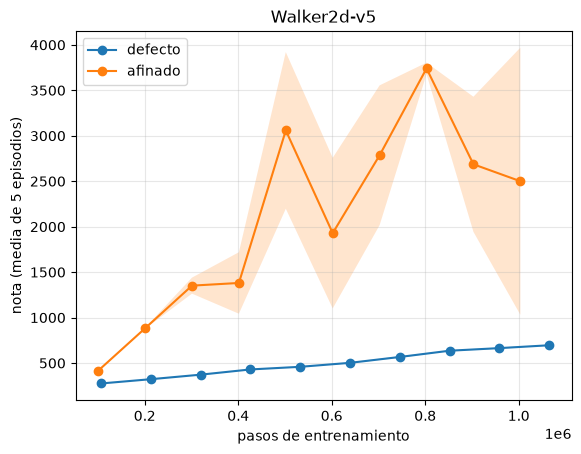

In [12]:
walker_defecto = [(106_496, 275.4, 2.5), (212_992, 322.4, 2.5), (319_488, 372.2, 1.8), (425_984, 429.6, 1.4),
                  (532_480, 458.6, 1.9), (638_976, 502.3, 4.7), (745_472, 566.8, 7.7), (851_968, 635.6, 3.4),
                  (958_464, 664.2, 7.3), (1_064_960, 695.6, 1.6)]
walker_afinado = [(100_352, 415.6, 3.2), (200_704, 882.1, 5.3), (301_056, 1351.5, 88.1), (401_408, 1380.8, 338.1),
                  (501_760, 3058.7, 861.2), (602_112, 1929.2, 828.4), (702_464, 2785.6, 768.8), (802_816, 3740.6, 63.7),
                  (903_168, 2686.3, 743.1), (1_003_520, 2500.1, 1468.6)]

dibujar_registro("Walker2d-v5", {"defecto": walker_defecto, "afinado": walker_afinado})


Aquí la diferencia es enorme:

- **`defecto` sube lentísimo**: de 275 a 696 puntos en un millón de pasos, y con una franja finísima (todos los episodios iguales). Lo he examinado aparte con los mismos 10 episodios: dura unos **164 pasos** (1,3 s) y recorre **4,3 m**, a más de 3 m/s. Lo que ha aprendido es a **lanzarse hacia delante** a toda velocidad y caerse (lo mismo que verás en el ejercicio E6). Es un **óptimo local** (NB17): cada pequeña mejora de "lanzarse mejor" sube un poco la nota, pero aprender a andar de verdad exigiría pasar antes por un tramo en el que la nota **baja**.
- **`afinado` sí aprende a andar**: supera los 3.000 puntos a los 500.000 pasos y llega a **3.741** a los 800.000. Una explicación probable: con dos piernas, la campana ancha de `defecto` (σ = 1 al empezar, NB30) produce movimientos tan bruscos que casi nunca se mantiene en pie el tiempo suficiente para descubrir el ritmo de los pasos; la campana más estrecha de `afinado` (σ ≈ 0,37) explora con más calma.
- Pero **`afinado` es muy inestable**: 3.059 → 1.929 → 2.786 → 3.741 → 2.686 → 2.500, con franjas de ±800 y hasta **±1.469** en el último tramo. Es decir, unos episodios anda de maravilla y otros se cae enseguida.

Un millón de pasos se le queda **corto** a Walker2d: en los artículos de investigación se entrena con varios millones (sección 9). Cargamos `afinado` (su último tramo) y lo examinamos con 10 episodios:


Walker2d entrenado: retorno  3160.9 | dura  849.2 pasos | recorre 18.52 m en 6.8 s (≈ 2.73 m/s)


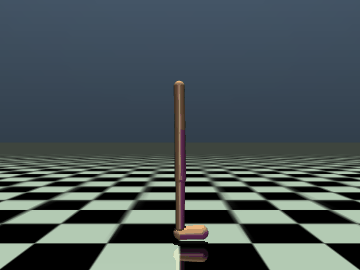

In [13]:
agente_walker, normalizador_walker = cargar("Walker2d-v5", "afinado")
politica_walker = politica_de(agente_walker, normalizador_walker)
r, d, x = jugar_episodios(walker, politica_walker)
print(f"Walker2d entrenado: retorno {r:7.1f} | dura {d:6.1f} pasos | recorre {x:5.2f} m en {d * 0.008:.1f} s "
      f"(≈ {x / (d * 0.008):.2f} m/s)")

n = grabar("Walker2d-v5", politica_walker, "assets/nb35_walker.gif")
Image(filename="assets/nb35_walker.gif")


**3.161 puntos**, **849 pasos** de media, **18,5 metros** a **2,73 m/s**. Más que los 2.500 de su último tramo del registro: con una política tan inestable, la nota depende mucho de **qué episodios** le toquen (aquí 10, con semillas 0 a 9; en el registro, 5 con la semilla 123). Moraleja: cuando la desviación es tan grande, **5 episodios no bastan** para juzgar a un agente.

Y mira **cómo** anda, porque es muy curioso:

1. Durante **más de un segundo**, se queda **casi quieto**, de pie, con las piernas juntas, haciendo pequeños ajustes. Va cobrando sus +1 por sobrevivir sin arriesgar nada.
2. Entonces **inclina el torso muchísimo hacia delante**, como si se fuese a caer de bruces... y empieza a dar **zancadas grandes y rápidas**, lanzando las piernas por delante para no caerse. Literalmente, anda **cayéndose hacia delante** y recogiéndose en cada paso. (Recuerda que a Walker2d se le permite inclinarse hasta 1 radián, unos 57°.)

## 8 · Formas raras de andar

Si has visto los GIF con atención, quizá te hayan parecido algo **raros**. Es normal, y es una de las lecciones más importantes de la robótica con RL: **la recompensa no dice "anda bonito"**. Dice
"avanza deprisa, no te caigas y no gastes mucha fuerza". Cualquier forma de moverse que cumpla eso vale lo mismo para el agente, aunque a nosotros nos parezca absurda: arrastrar un pie, ir dando
saltitos con las dos piernas juntas, avanzar de rodillas inclinado...

Y esto no es un problema "de juguete". Los robots reales entrenados así tienen que **funcionar en el mundo real**, y los andares raros suelen ser malos allí: golpean el suelo con fuerza (rompen
piezas), dependen de detalles de la simulación que no son exactos (el **reality gap** del NB02) o gastan mucha energía. Por eso, en los proyectos de verdad, la recompensa lleva **muchos más
términos**: premios por levantar los pies a cierta altura, por un ritmo de pasos regular, castigos por golpes fuertes, por mover las articulaciones a tirones... Diseñar esa recompensa (*reward
shaping*, "moldear la recompensa") es buena parte del trabajo de un ingeniero de locomoción. Lo veremos en la parte de bípedos.


## 9 · Más grande: Colab

Un millón de pasos en la Pi es el límite de lo cómodo. Para ir más allá (el humanoide necesita **decenas de millones**), se usa una máquina con más núcleos o una **GPU**. El mismo script funciona
en **Google Colab** (gratis, NB31) sin cambiar nada; solo hay que instalar lo que falta. En una celda de Colab:

```python
!pip install "stable-baselines3[extra]" "gymnasium[mujoco]"
!wget -q https://raw.githubusercontent.com/Greg2828/robotica/main/notebooks/entrenar_largo.py
!python entrenar_largo.py Walker2d-v5 afinado 3000000
```

(La `!` al principio de una línea de un cuaderno ejecuta una orden de la **terminal**, NB26.) Y un detalle de profesional: para redes tan pequeñas como estas, la GPU apenas ayuda; lo que acelera es
tener **más entornos en paralelo** (más núcleos de CPU). La GPU marca la diferencia cuando también la **simulación** corre en ella, como con MuJoCo Playground o Isaac Lab: miles de robots a la vez.
Eso lo haremos en la parte de bípedos.


## 10 · Resumen de la lección

1. Con **patas** aparecen los **contactos** (empujar el suelo, aterrizar), las **fases en el aire**, la **subactuación** del propio cuerpo y el **ritmo** de los pasos.
2. **Hopper-v5**: torso, muslo, pierna y pie; 3 motores (×200); observa 11 números (sin su x); decide 125 veces por segundo; episodios de hasta 1.000 pasos (8 s).
3. Recompensa = **sobrevivir** (+1 si está sano) + **avanzar** (velocidad) − **gastar** (0,001 × acciones²); el diccionario `info` la desglosa. "Sano" = altura, inclinación y estado dentro de límites.
4. **La trampa de sobrevivir**: sin el término de avance, el agente aprende a **quedarse** de pie (reward hacking, NB04).
5. **`VecNormalize`** normaliza observaciones y recompensas con medias y desviaciones móviles. Trampas: guardar **también** sus estadísticas; al evaluar, `training=False` y `norm_reward=False`.
6. Entrenamiento largo (1M de pasos) con un script, cargado con `PPO.load` + `VecNormalize.load`, examinado y grabado. **Walker2d-v5**: 6 motores, 17 observaciones, misma recompensa.
7. La recompensa no dice "anda bonito": aparecen **andares raros**. En los proyectos reales se **moldea** la recompensa con muchos más términos.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Hopper / Walker2d** | Robots planos de MuJoCo con una y dos piernas. |
| **Contacto** | Que un pie toque (o no) el suelo; el único modo de empujarse. |
| **Fase en el aire** | Momento sin ningún pie en el suelo. |
| **Multiplicador (*gear*)** | Lo que convierte una acción de −1 a 1 en par de giro del motor. |
| **Recompensa de vida (*healthy reward*)** | +1 por paso mientras el robot está sano. |
| **`unwrapped`** | El entorno sin envoltorios, para consultar sus entrañas. |
| **`env_kwargs`** | Argumentos para crear cada copia en `make_vec_env`. |
| **`VecNormalize` / `obs_rms`** | Envoltorio que normaliza observaciones y recompensas / sus estadísticas. |
| **Andar raro** | Forma de moverse que cumple la recompensa pero no es natural ni útil en la realidad. |
| **Moldear la recompensa (*reward shaping*)** | Añadir términos a la recompensa para guiar cómo se mueve el robot. |


## 11 · Ejercicios

**E1.** En un paso, Hopper está sano, avanza a 1,5 m/s y sus acciones son (0,5; −1; 0,2). Calcula su recompensa a mano.

**E2.** Un Hopper que se queda de pie perfecto, sin moverse, los 1.000 pasos, ¿cuántos puntos saca? ¿Y uno que avanza a 2 m/s durante 300 pasos y luego se cae? ¿Cuál "prefiere" la recompensa?

**E3.** ¿Por qué crees que la observación **no** incluye la posición x del robot? ¿Qué podría pasar si la incluyera?

**E4.** Carga el Hopper entrenado y examínalo con el **término de control 100 veces más caro**: `gym.make("Hopper-v5", ctrl_cost_weight=0.1)`. ¿Cuánto saca? ¿Hace falta reentrenar para que se
adapte?

**E5.** Usa el Walker2d entrenado **sin** la normalización (pasándole las observaciones crudas: `lambda obs: agente_walker.predict(obs, deterministic=True)[0]`). ¿Qué pasa?

**E6.** **Reto.** Entrena 106.496 pasos un Hopper con `healthy_reward=0` (sin premio por sobrevivir). ¿Qué crees que hará? Compruébalo y explícalo.


<details>
<summary>▶ Solución E1</summary>

Sobrevivir: +1. Avanzar: +1,5. Gastar: 0,001 × (0,5² + 1² + 0,2²) = 0,001 × (0,25 + 1 + 0,04) = 0,00129. Total: 1 + 1,5 − 0,00129 ≈ **2,499**. El gasto es tan pequeño que casi no se nota: el castigo de
control solo importa cuando se acumula durante muchos pasos con acciones grandes.
</details>

<details>
<summary>▶ Solución E2</summary>

De pie quieto: 1.000 × 1 = **1.000** puntos. El que avanza: 300 × (1 + 2) = **900** puntos (y luego nada, porque se cae). ¡La recompensa **prefiere** al que se queda quieto! Por eso al principio del
entrenamiento hay que tener cuidado: si aprende antes a no caerse que a avanzar, puede quedarse atascado en "de pie". En cambio, uno que avanza a 2 m/s **sin caerse** los 1.000 pasos saca 3.000, y ese
es el premio gordo que acaba encontrando PPO.
</details>

<details>
<summary>▶ Solución E3</summary>

Andar bien no depende de **dónde** estás: el mismo paso sirve en el metro 1 y en el metro 50. Si la red viera la x, podría aprender reglas que dependen del sitio ("en x = 3, salta") que no tienen sentido
y que no le servirían en cuanto llegase a un sitio que no vio al entrenar (por ejemplo, el metro 100, si al entrenar nunca pasó del 20). Quitarle la x es una forma de obligarla a **generalizar**. Es
una decisión de **diseño de la observación**, tan importante como diseñar la recompensa.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
hopper_caro = gym.make("Hopper-v5", ctrl_cost_weight=0.1)
print(jugar_episodios(hopper_caro, politica_hopper))
```

Sale `(3482.1, 969.1, 20.73)`: los **mismos** 969 pasos y los **mismos** 20,73 m que antes. La política hace **exactamente lo mismo**: no sabe nada de la recompensa (solo ve observaciones y devuelve acciones). Lo único que cambia es la **nota**: de 3.558,8 a 3.482,1, unos 77 puntos menos.

De ahí se puede sacar cuánto gastaba antes: 100 veces más caro resta 99 veces el gasto original, así que el gasto original era 77 / 99 ≈ **0,78 puntos** en todo el episodio. Diminuto.

¿Hace falta reentrenar? Para que el robot **cambie** su forma de moverse y use menos fuerza, **sí**: la recompensa solo influye **al aprender**. Pero aquí no merece la pena: incluso 100 veces más caro, el gasto es solo un 2 % de la nota.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
print(jugar_episodios(walker, lambda obs: agente_walker.predict(obs, deterministic=True)[0]))
```

Sale `(317.0, 194.5, 0.99)`: se cae en unos 195 pasos (1,6 s) después de avanzar apenas **1 metro**, cuando con la normalización sacaba 3.161 y andaba 18 m. La red recibe números en una escala que **nunca** vio al entrenar (por ejemplo, una altura de 1,25 m en vez del número normalizado, cercano a 0, que estaba acostumbrada a leer), y sus decisiones dejan de tener sentido. Es la **primera trampa** de la sección 5: las estadísticas de `VecNormalize` son **parte del agente**. Sin ellas, el agente está "ciego".
</details>

<details>
<summary>▶ Solución E6</summary>

```python
agente_sin_vida = PPO("MlpPolicy", make_vec_env("Hopper-v5", n_envs=4, seed=0, env_kwargs=dict(healthy_reward=0.0)), seed=0)
agente_sin_vida.learn(total_timesteps=106_496)
print(jugar_episodios(gym.make("Hopper-v5", healthy_reward=0.0), lambda obs: agente_sin_vida.predict(obs, deterministic=True)[0]))
```

Sale aproximadamente `(227.6, 133.9, 1.82)`: dura unos 134 pasos (1,07 s) y recorre **1,8 m**, a más de 1,6 m/s... y se cae. Se **lanza en plancha** hacia delante.

¿Por qué? Sin premio por sobrevivir, **caerse no cuesta nada**: lo único que da puntos es avanzar. La forma más rápida de avanzar al principio es tirarse hacia delante, y como después de caerse no se pierde nada, no hay motivo para aprender a mantenerse en pie. Es la **trampa contraria** a la de la sección 4: allí no se movía por miedo a caerse; aquí se cae porque no le importa. (Y es justo lo que aprendió el Walker2d `defecto`.) Una buena recompensa necesita **los dos** términos, equilibrados.
</details>


## 12 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Con este notebook se cierra la **Parte 4**: has pasado de lanzar una moneda (NB28) a entrenar robots con patas en un simulador de física real con el algoritmo que usa la industria, entendiendo
cada pieza por dentro. Lo siguiente es la **Parte 5 · La física del cuerpo**: por qué los robots se caen (centro de masas, base de apoyo, el punto de momento cero), cómo funcionan de verdad los motores
y los sensores, y cómo se describe un robot en un fichero de MuJoCo. Con eso podrás **construir y modificar** tus propios cuerpos, y no solo usar los que vienen hechos.
